In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import logging
logger = tf.get_logger()
logger.setLevel(logging.ERROR)

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from sklearn.metrics import confusion_matrix

In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input

train_datagen = image.ImageDataGenerator(
    preprocessing_function=preprocess_input,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
)
validation_datagen = image.ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [ ]:
train = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/Research/original_data_leveling/up_train',
    target_size = (224, 224),
    batch_size = 32,
    class_mode = 'categorical'
)

validation = validation_datagen.flow_from_directory(
    '/content/drive/MyDrive/Research/original_data_leveling/up_val',
    target_size = (224, 224),
    batch_size = 32,
    class_mode = 'categorical'
)

test = validation_datagen.flow_from_directory(
    '/content/drive/MyDrive/Research/original_data_leveling/up_test',
    target_size = (224, 224),
    batch_size = 32,
    shuffle = False,
    class_mode = 'categorical'
)

Found 10500 images belonging to 3 classes.
Found 1500 images belonging to 3 classes.
Found 3000 images belonging to 3 classes.


In [ ]:
ResNet50 = tf.keras.applications.ResNet50(
    include_top=False,
    weights = 'imagenet',
    input_shape=(224,224,3),
    )

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
ResNet50.trainable = False

In [ ]:
model = tf.keras.models.Sequential([
  ResNet50,
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dropout(0.9),
  tf.keras.layers.Dense(units=1024, activation='relu'),
  tf.keras.layers.Dense(units=512, activation='relu'),
  tf.keras.layers.Dense(units=3, activation='softmax'),
])

In [ ]:
model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │   102,761,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,875,523 (483.99 MB)

 Trainable params: 103,287,811 (394.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
history = model.fit(
    x = train,
    validation_data = validation,
    epochs = 10
)

Epoch 1/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 5907s 18s/step - accuracy: 0.8747 - loss: 0.8554 - val_accuracy: 0.9167 - val_loss: 0.2000
Epoch 2/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 188s 572ms/step - accuracy: 0.9169 - loss: 0.2400 - val_accuracy: 0.9580 - val_loss: 0.0955
Epoch 3/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 189s 573ms/step - accuracy: 0.9329 - loss: 0.1750 - val_accuracy: 0.9673 - val_loss: 0.0881
Epoch 4/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 188s 572ms/step - accuracy: 0.9411 - loss: 0.1539 - val_accuracy: 0.9733 - val_loss: 0.0674
Epoch 5/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 189s 574ms/step - accuracy: 0.9464 - loss: 0.1359 - val_accuracy: 0.9753 - val_loss: 0.0742
Epoch 6/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 186s 567ms/step - accuracy: 0.9503 - loss: 0.1313 - val_accuracy: 0.9753 - val_loss: 0.0625
Epoch 7/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 186s 564ms/step - accuracy: 0.9545 - loss: 0.1225 - val_accuracy: 0.9787 - val_loss: 0.0559
Epoch 8/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 185s 563ms/step - accuracy: 0.9565 - 

In [ ]:
# Evaluate the loss and accuracy
loss, accuracy = model.evaluate(test)

# Print the accuracy
print("Accuracy: " + str(accuracy))
# Print the loss
print("Loss: " + str(loss))

94/94 ━━━━━━━━━━━━━━━━━━━━ 2033s 22s/step - accuracy: 0.9830 - loss: 0.0575
Accuracy: 0.9829999804496765
Loss: 0.0574667751789093


In [ ]:
test.class_indices

{'Lung_Adenocarcinoma': 0,
 'Lung_Benign_Tissue': 1,
 'Lung_Squamos_Cell_Carcinoma': 2}

In [ ]:
import numpy as np
from sklearn import metrics

predictions = model.predict(test)
predicted_classes = np.argmax(predictions, axis = 1)
true_classes = test.classes
class_labels = ['Lung_Adenocarcinoma', 'Lung_Benign_Tissue', 'Lung_Squamous_Cell_Carcinoma']
report = metrics.classification_report(true_classes, predicted_classes, target_names = class_labels)
print(report)

94/94 ━━━━━━━━━━━━━━━━━━━━ 33s 289ms/step
                              precision    recall  f1-score   support

         Lung_Adenocarcinoma       0.96      0.99      0.97      1000
          Lung_Benign_Tissue       1.00      1.00      1.00      1000
Lung_Squamous_Cell_Carcinoma       0.99      0.96      0.97      1000

                    accuracy                           0.98      3000
                   macro avg       0.98      0.98      0.98      3000
                weighted avg       0.98      0.98      0.98      3000



<Axes: >

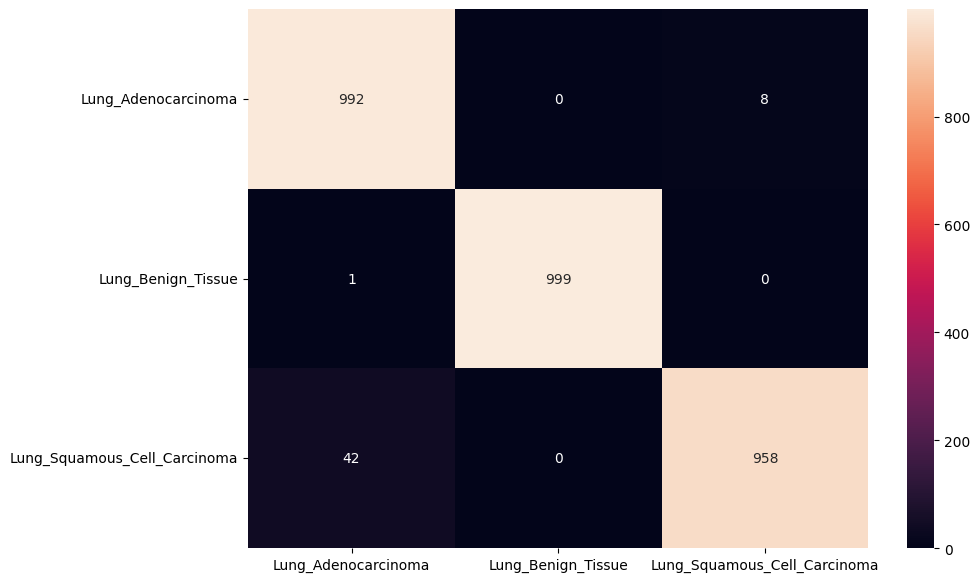

In [ ]:
import seaborn as sn
import pandas as pd
import matplotlib.pyplot as plt

# Label order MUST match test.class_indices: Adenocarcinoma=0, Benign=1, Squamous=2
labels = ['Lung_Adenocarcinoma', 'Lung_Benign_Tissue', 'Lung_Squamous_Cell_Carcinoma']
cm = metrics.confusion_matrix(true_classes, predicted_classes)
df_cm = pd.DataFrame(cm, index=labels, columns=labels)
plt.figure(figsize = (10,7))
sn.heatmap(df_cm, annot=True, fmt='d')

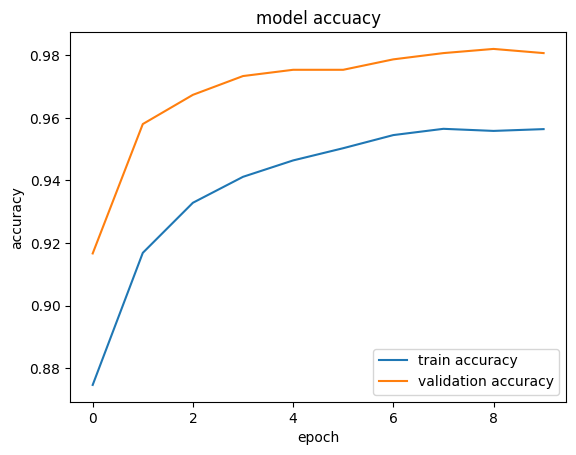

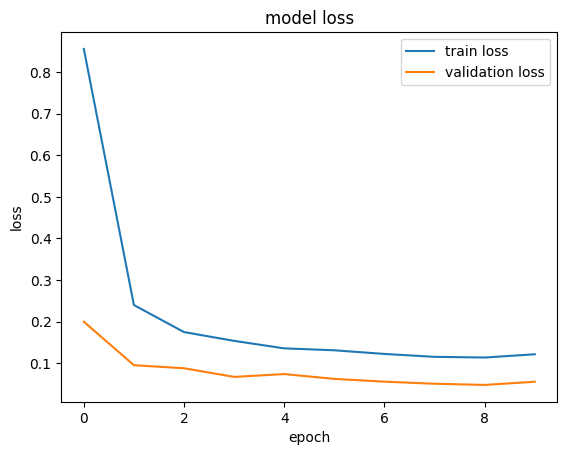

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("model accuacy")
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train accuracy', 'validation accuracy'], loc='lower right')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train loss', 'validation loss'], loc='upper right')
plt.show()